In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

from functions.utils import load_config
config = load_config() 



# get mapping similarity and remove exact mappings 

Text(0, 0.5, 'Number of EHRSHOT Concepts mapping to SNOMED CT')

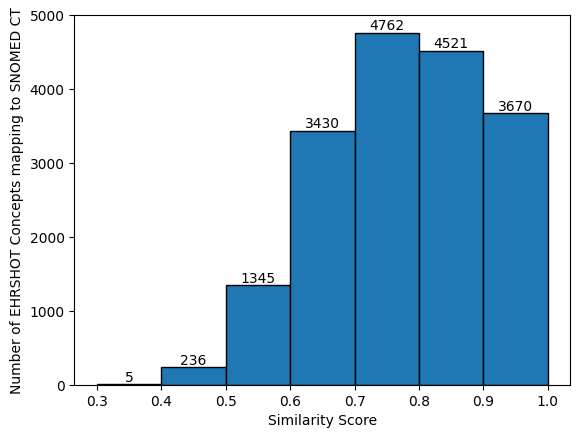

In [29]:
df_mapping = pl.read_excel("temp/mapping_concept_ehrshot_to_snomedct.xlsx").filter(pl.col("exact_to_snomed") == False).filter(pl.col("similarity_score")<0.99)

# put the exact counts on top of the bars
counts, bins, patches = plt.hist(df_mapping["similarity_score"], bins=np.arange(0.3, 1.1, 0.1), edgecolor='black')
for count, bin, patch in zip(counts, bins, patches):
    if count > 0:
        plt.text(bin + 0.05, count + 1, str(int(count)), ha='center', va='bottom')  
plt.xlabel("Similarity Score")
plt.ylabel("Number of EHRSHOT Concepts mapping to SNOMED CT")

# sample according to interval

In [32]:
sample_count_list = [5, 40, 60, 120,200,200,120]
interval_labels = np.arange(0.3, 1.1, 0.1) 
df_sample_all = pl.DataFrame()
for label, sample_count in zip(interval_labels, sample_count_list):
    df_sample = (df_mapping.filter(
        (pl.col("similarity_score") >= label) & 
        (pl.col("similarity_score") < label + 0.1)
    ).sample(n=sample_count, with_replacement=False, seed=42)
    .with_columns(category=pl.lit(f"{label:.1f} - {label + 0.1:.1f}")))
    df_sample_all = pl.concat((df_sample_all, df_sample))
    


In [37]:
df_sample_all.drop(["exact_to_snomed", "data_volume_per"]).write_excel("temp/sampled_concepts_for_manual_review.xlsx")



In [39]:
df_sample_all


exact_to_snomed,ehrshot_concept_id,ehrshot_concept_original_ontology,ehrshot_label,frequency,best_matched_snomed_concept_id,best_matched_snomed_label,similarity_score,data_volume_per,category
bool,str,str,str,i64,str,str,f64,f64,str
false,"""0WWG4JZ""","""ICD10PCS""","""Revision of Synthetic Substitu…",3,"""443016003""","""CT guided percutaneous drainag…",0.371564,4.8869e-8,"""0.3 - 0.4"""
false,"""43399-5""","""LOINC""","""JAK2 gene p.Val617Phe [Presenc…",12,"""770714009""","""Allergy to coagulation factor …",0.375757,1.9548e-7,"""0.3 - 0.4"""
false,"""0PU00JZ""","""ICD10PCS""","""Supplement Sternum with Synthe…",2,"""87225004""","""Open fracture sternum""",0.388881,3.2579e-8,"""0.3 - 0.4"""
false,"""0PR30KZ""","""ICD10PCS""","""Replacement of Cervical Verteb…",1,"""440143005""","""Closed reduction of closed non…",0.371916,1.6290e-8,"""0.3 - 0.4"""
false,"""01U10KZ""","""ICD10PCS""","""Supplement Cervical Nerve with…",1,"""298442006""","""Decreased active range of cerv…",0.386268,1.6290e-8,"""0.3 - 0.4"""
…,…,…,…,…,…,…,…,…,…
false,"""25065""","""CPT4""","""Biopsy, soft tissue of forearm…",1,"""90105005""","""Biopsy of soft tissue of forea…",0.915065,1.6290e-8,"""0.9 - 1.0"""
false,"""84132""","""CPT4""","""Potassium; serum, plasma or wh…",1,"""312468003""","""Blood potassium level""",0.932349,1.6290e-8,"""0.9 - 1.0"""
false,"""31437008""","""SNOMED""","""Lymphocytic-plasmacytic coliti…",22,"""235753003""","""Lymphocytic colitis""",0.900825,3.5837e-7,"""0.9 - 1.0"""
